# 텍스트 빈도수 시각화 : 단어 빈도 그래프, 워드클라우드
1. 데이터 수집(로딩)
1. 텍스트 전처리
1. 빈도수 계산
1. 단어 빈도 그래프 시각화
1. 워드클라우드 시각화

## 1. 데이터 수집(로딩)

In [3]:
# 실습 문서 : 대한민국 헌법
from konlpy.corpus import kolaw
input_filename = 'constitution.txt'
const_doc = kolaw.open(input_filename).read()

#가져온 데이터 확인 (타입, 길이, 일부 데이터)
type(const_doc), len(const_doc), const_doc[:50]

(str, 18884, '대한민국헌법\n\n유구한 역사와 전통에 빛나는 우리 대한국민은 3·1운동으로 건립된 대한민국임')

## 2. 텍스트 전처리
* 한글 : 품사 태깅 -> 필요 품사 단어만 사용 -> 불용어 삭제

In [7]:
from konlpy.tag import Okt
tagger = Okt()

# 명사만 추출
noun_list = tagger.nouns(const_doc)

# 토큰 수
print(len(noun_list))

# 토큰 일부 확인
print(noun_list[:10])

3882
['대한민국', '헌법', '유구', '역사', '전통', '우리', '국민', '운동', '건립', '대한민국']


In [13]:
# 명사(일반 명사, 고유 명사), 동사, 형용사 단어 추출
# 품사 태깅 -> 명사, 동사, 형용사에 해당하는 토큰만 모으기
pos_list = tagger.pos(const_doc)
print(len(pos_list))
print(pos_list[:10])

my_tags = ['Noun', 'Verb', 'Adjective']
my_tokens = [word for word, tag in pos_list if tag in my_tags]

# 토큰 수
print(f'사용할 토큰 수 : {len(my_tokens):,}')
# 토큰 일부 확인
print(my_tokens[:10])

8796
[('대한민국', 'Noun'), ('헌법', 'Noun'), ('\n\n', 'Foreign'), ('유구', 'Noun'), ('한', 'Josa'), ('역사', 'Noun'), ('와', 'Josa'), ('전통', 'Noun'), ('에', 'Josa'), ('빛나는', 'Verb')]
사용할 토큰 수 : 5,046
['대한민국', '헌법', '유구', '역사', '전통', '빛나는', '우리', '국민', '운동', '건립']


In [15]:
# 불용어 삭제 : 의미없는데 고빈도로 나오는 단어 추가
my_stopwords = ['된', '입']
my_new_tokens =[token for token in my_tokens if token not in my_stopwords]

# 토큰 수
print(f'불용어 제거 후 토큰 수 : {len(my_new_tokens):,}')

# 토큰 일부 확인
print(my_new_tokens[:100])

my_tokens = my_new_tokens

불용어 제거 후 토큰 수 : 5,015
['대한민국', '헌법', '유구', '역사', '전통', '빛나는', '우리', '국민', '운동', '건립', '대한민국', '임시정부', '법', '통과', '불의', '항거', '민주', '이념', '계승', '조국', '민주', '개혁', '평화', '통일', '사명', '각하', '정의', '인도', '동포', '애', '로써', '민족', '단결', '공고', '하고', '모든', '사회', '폐습', '불의', '타파', '하며', '자율', '조화', '바탕', '자유민주', '질서', '더욱', '확고히', '하여', '정치', '경제', '사회', '문화', '모든', '영역', '있어서', '각인', '기회', '균등히', '하고', '능력', '최고', '도로', '발휘', '하게', '하며', '자유', '권리', '따르는', '책임', '의무', '완수', '하게', '하여', '안', '국민', '생활', '균등한', '향상', '기하', '밖', '항구', '세계', '평화', '인류', '공영', '이바지', '함', '우리', '우리', '자손', '안전', '자유', '행복', '영원히', '확보', '할', '것', '다짐', '하면서']


## 3.  빈도수 계산

In [17]:
# Counter 객체 생성
from collections import Counter
const_counter = Counter(my_tokens)

# 단어 수
len(const_counter)


# Co단어, 빈도수) 확인
print(list(const_counter.items())[:20])

[('대한민국', 11), ('헌법', 53), ('유구', 1), ('역사', 1), ('전통', 1), ('빛나는', 1), ('우리', 3), ('국민', 61), ('운동', 2), ('건립', 1), ('된', 30), ('임시정부', 1), ('법', 3), ('통과', 1), ('불의', 2), ('항거', 1), ('민주', 6), ('이념', 1), ('계승', 2), ('조국', 3)]


In [19]:
# 빈도수 상위 단어의 (단어, 빈도수) 튜플 리스트 추출
const_counter.most_common(20)

[('제', 175),
 ('한다', 155),
 ('법률', 127),
 ('할', 100),
 ('정', 89),
 ('수', 88),
 ('대통령', 83),
 ('국가', 73),
 ('국회', 68),
 ('의하여', 66),
 ('하는', 64),
 ('국민', 61),
 ('하여', 61),
 ('관', 58),
 ('있다', 57),
 ('때', 55),
 ('헌법', 53),
 ('그', 47),
 ('이', 38),
 ('모든', 37)]

## 4. 단어 빈도 그래프 시각화
1. 데이터 준비
2. 그래프 정보 추가
3. 막대 그래프 생성
4. 그래프 출력 (화면, 파일)

In [21]:
# 데이터 준비 : 빈도수 상위 20개의 단어만 추출
# x 데이터 : word, y 데이터 : count

most_freq_list = const_counter.most_common(20)
print(most_freq_list)

# x 데이터 : word, y 데이터 : count
x_list = [word for word, count in most_freq_list]
y_list = [count for word, count in most_freq_list]
print("x 데이터 :", x_list)
print("y 데이터 :", y_list)

[('제', 175), ('한다', 155), ('법률', 127), ('할', 100), ('정', 89), ('수', 88), ('대통령', 83), ('국가', 73), ('국회', 68), ('의하여', 66), ('하는', 64), ('국민', 61), ('하여', 61), ('관', 58), ('있다', 57), ('때', 55), ('헌법', 53), ('그', 47), ('이', 38), ('모든', 37)]
x 데이터 : ['제', '한다', '법률', '할', '정', '수', '대통령', '국가', '국회', '의하여', '하는', '국민', '하여', '관', '있다', '때', '헌법', '그', '이', '모든']
y 데이터 : [175, 155, 127, 100, 89, 88, 83, 73, 68, 66, 64, 61, 61, 58, 57, 55, 53, 47, 38, 37]


In [25]:
# matplotlib 한글 폰트 설정
from matplotlib import font_manager, rc
font_path = "c:/Windows/Fonts/malgun.ttf"
font_name = font_manager.FontProperties(fname=font_path).get_name()
rc('font', family=font_name)

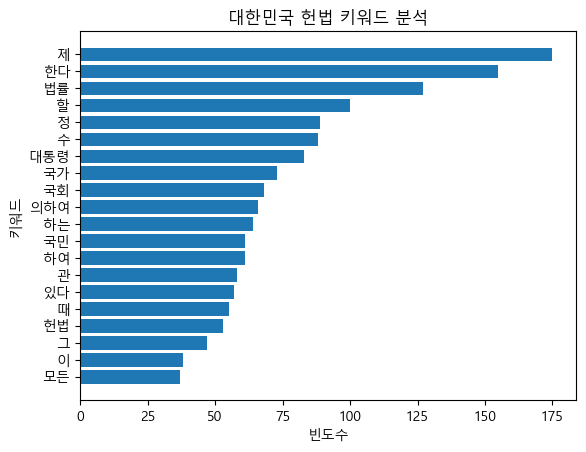

In [26]:
import matplotlib.pyplot as plt

# 수평 막대그래프
plt.barh(x_list[::-1], y_list[::-1])
# 그래프 정보 추가 
plt.title('대한민국 헌법 키워드 분석')
plt.xlabel('빈도수')
plt.ylabel('키워드')

# 화면에 출력
plt.show()

./result/constitution_graph.jpg


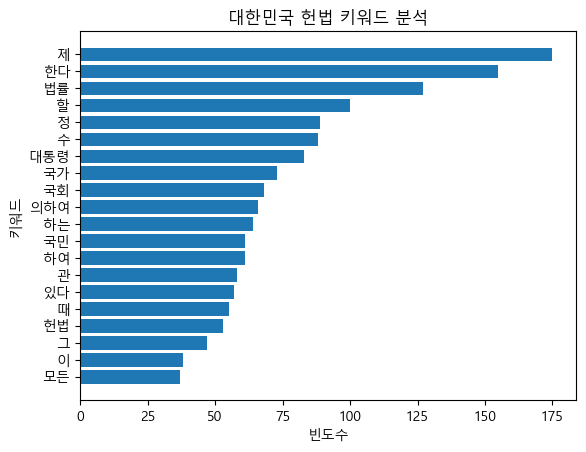

In [29]:

# 수평 막대그래프
plt.barh(x_list[::-1], y_list[::-1])
# 그래프 정보 추가 
plt.title('대한민국 헌법 키워드 분석')
plt.xlabel('빈도수')
plt.ylabel('키워드')

# 그래프 저장 : 그래프 생성 후 바로 savefig 사용
result_filename = './result/' + input_filename.replace('.txt', '_graph.jpg')
plt.savefig(result_filename)

### 03-5. 워드 클라우드 시각화

* conda 환경에서 wordcloud 설치 (conda install wordcloud)

In [36]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# 한글 폰트 path 지정
font_path = "c:/Windows/fonts/malgun.ttf"

# WordCloud 객체 생성
const_wc = WordCloud(
    font_path = font_path,
    width = 800,
    height = 600,
    max_words = 50,
    background_color='ivory'
)

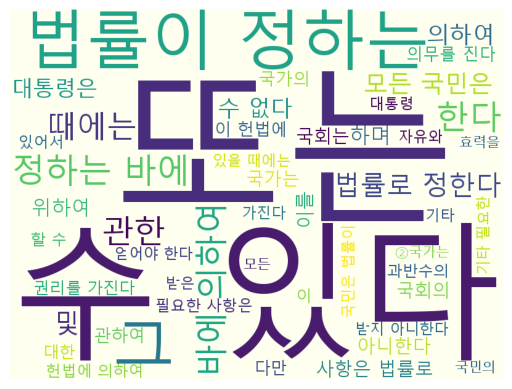

In [37]:
# 전체 텍스트로 워드클라우드 시각화
const_wc = const_wc.generate(const_doc)

plt.imshow(const_wc)
plt.axis('off')
plt.show()

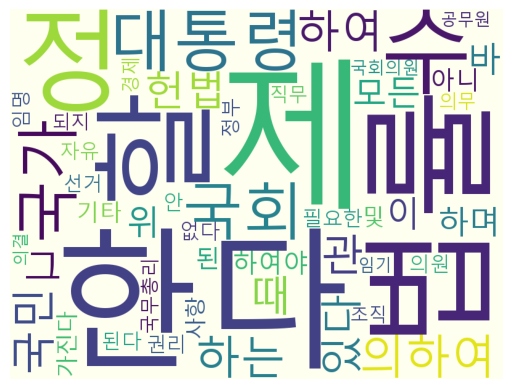

In [39]:
# 빈도 데이터로 워드클라우드 시각화
const_wc = const_wc.generate_from_frequencies(const_counter)
plt.imshow(const_wc)
plt.axis('off')
plt.show()

In [40]:
# wordcloud 이미지 저장
result_filename = './result/' + input_filename.replace('.txt', '_wordcloud.jpg')
const_wc.to_file(result_filename)